# Feature Selection/Extraction
In this project we will use the library scikit-learn to work with the league of legends dataset we will apply some feature selection techniques and experiment with dimensionality reduction by using:
1. Principal Component Analysis (PCA)
2. Linear Discriminant Analysis (LDA)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import fetch_openml
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import DecisionBoundaryDisplay

We load the league of legends data from kaggle, the `X` data contains information about the league of legends games, we will be using that data to predict the class `y`, which tells us if a match is won or not. 
The details on the different features name and definition can be found here: https://www.kaggle.com/datasets/nathansmallcalder/lol-match-history-and-summoner-data-80k-matches/data?select=MatchStatsTbl.csv

In [2]:
df = pd.read_csv(r"C:\Users\fenos\Documents\stuff\jupyter\Machine Learning 2025_2026\MatchStatsTbl.csv") #!!!change the file directory to your own file directory path

X = df.copy()
y = df["Win"].astype(int)


## Exploring the Data 


Let's explore the dataset using head(), info(), and describe() from pandas to review feature types and identify missing data.

In [3]:
print(X.head())
print(X.info())
print(X.describe())

   MatchStatsId  SummonerMatchFk  MinionsKilled  DmgDealt  DmgTaken  \
0             1                1             30      4765     12541   
1             2                2             29      8821     14534   
2             3                3             34      6410     19011   
3             4                4             51     22206     14771   
4             5                5              0     39106     33572   

   TurretDmgDealt  TotalGold    Lane  Win  item1  ...  PrimarySlot3  \
0               0       7058  BOTTOM    0   3870  ...          8453   
1               1       9618  BOTTOM    0   3870  ...          8453   
2               3       9877  BOTTOM    1   3870  ...          8237   
3               3      12374    NONE    1   6655  ...          8106   
4               0      15012     TOP    1   4015  ...             0   

   SecondarySlot1  SecondarySlot2  SummonerSpell1  SummonerSpell2  \
0            8345            8347               4               7   
1       

### Dropping useless features
Now, we are going to drop the `MatchStatsId` and `SummonerMatchFk` features which are not very informative since they are numbers of the match to identify it.

We also drop the `Win` feature from X since we want to predict it and not have it as a feature in this case. (We could also study what was the champions picked, gold lead etc. considering win as a feature)


In [4]:
# drop function panda
X.drop(["Win", "MatchStatsId", "SummonerMatchFk"], axis=1, inplace=True)


### Dropping missing values
We will check if any of the remaining features have missing values using `isnull()` and remove those with missing value ratios above 25% using the function `drop()` from `pandas`. 

In [5]:
print(X.isnull().mean())

MinionsKilled           0.0
DmgDealt                0.0
DmgTaken                0.0
TurretDmgDealt          0.0
TotalGold               0.0
Lane                    0.0
item1                   0.0
item2                   0.0
item3                   0.0
item4                   0.0
item5                   0.0
item6                   0.0
kills                   0.0
deaths                  0.0
assists                 0.0
PrimaryKeyStone         0.0
PrimarySlot1            0.0
PrimarySlot2            0.0
PrimarySlot3            0.0
SecondarySlot1          0.0
SecondarySlot2          0.0
SummonerSpell1          0.0
SummonerSpell2          0.0
CurrentMasteryPoints    0.0
EnemyChampionFk         0.0
DragonKills             0.0
BaronKills              0.0
visionScore             0.0
dtype: float64


So we have nothing to drop since no missing values with over 0.25 threshold, actually all of these features are filled.

### Part 4
No features contain missing values, so no rows need to be dropped.

### Part 5
We will check which features are categorical and which are numerical. For the `lane` variable, we want to code a one-hot encoding. 

In [6]:
X.describe()
#X.dtypes

,MinionsKilled,DmgDealt,DmgTaken,TurretDmgDealt,TotalGold,item1,item2,item3,item4,item5,...,PrimarySlot3,SecondarySlot1,SecondarySlot2,SummonerSpell1,SummonerSpell2,CurrentMasteryPoints,EnemyChampionFk,DragonKills,BaronKills,visionScore
count,193758.000000,193758.000000,193758.000000,193758.000000,193758.000000,193758.000000,193758.000000,193758.000000,193758.000000,193758.000000,...,193758.000000,193758.000000,193758.000000,193758.000000,193758.000000,193758.000000,193758.000000,193758.000000,193758.000000,193758.000000
mean,108.712461,25219.012794,29940.714272,1.760536,12240.161557,37492.136268,35696.602499,46549.352693,31299.290151,30131.880227,...,7156.252867,7291.805061,7277.022187,284.030590,285.654419,207.004273,204.929949,0.290078,0.058872,19.930873
std,90.754678,17421.172395,17921.375493,1.962188,4596.605153,98895.209600,93965.720115,123692.335059,82464.036516,83316.387832,...,2718.202201,2777.116310,2771.151791,727.558006,726.897496,253.065805,255.889617,0.759657,0.255348,22.431461
min,0.000000,0.000000,0.000000,0.000000,500.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,23.000000,13237.000000,18701.000000,0.000000,9251.000000,3006.000000,3036.000000,3020.000000,3009.000000,1052.000000,...,8014.000000,8139.000000,8106.000000,4.000000,4.000000,48.000000,45.000000,0.000000,0.000000,3.000000
50%,97.500000,21716.000000,26732.000000,1.000000,11926.000000,3143.000000,3152.000000,3118.000000,3111.000000,3072.000000,...,8135.000000,8299.000000,8242.000000,4.000000,11.000000,105.000000,103.000000,0.000000,0.000000,15.000000
75%,188.000000,32715.000000,37405.000000,3.000000,14905.000000,6610.000000,6653.000000,4645.000000,4645.000000,4017.000000,...,8299.000000,8401.000000,8347.000000,14.000000,14.000000,235.000000,234.000000,0.000000,0.000000,25.000000
max,549.000000,314904.000000,435808.000000,12.000000,48347.000000,447123.000000,447123.000000,447123.000000,447123.000000,447123.000000,...,8453.000000,9111.000000,9111.000000,2202.000000,2202.000000,950.000000,950.000000,6.000000,4.000000,215.000000


In [7]:
#identification of categorical and numerical features
categorical_features = [col for col in X.columns if X[col].dtype == "object"]
numerical_features = [col for col in X.columns if col not in categorical_features]

print("Categorical features:", categorical_features)
print("Numerical features count:", len(numerical_features))

#onehot encoding
X = pd.get_dummies(X, columns=categorical_features, dtype=int)

X.info()



Categorical features: ['Lane']
Numerical features count: 27
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193758 entries, 0 to 193757
Data columns (total 33 columns):
 #   Column                Non-Null Count   Dtype
---  ------                --------------   -----
 0   MinionsKilled         193758 non-null  int64
 1   DmgDealt              193758 non-null  int64
 2   DmgTaken              193758 non-null  int64
 3   TurretDmgDealt        193758 non-null  int64
 4   TotalGold             193758 non-null  int64
 5   item1                 193758 non-null  int64
 6   item2                 193758 non-null  int64
 7   item3                 193758 non-null  int64
 8   item4                 193758 non-null  int64
 9   item5                 193758 non-null  int64
 10  item6                 193758 non-null  int64
 11  kills                 193758 non-null  int64
 12  deaths                193758 non-null  int64
 13  assists               193758 non-null  int64
 14  PrimaryKeyStone       19

### Part 6
We are going to split `X` and `y` into training and testing sets with 20% of the data in the testing set by using `rain_test_split()` from `sklearn`.

In [8]:
# split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2)

### Part 7
We will now train a classifier on the training dataset. 
For that, we will use a pipeline that preprocesses the data and then fits it into a classifier.

The idea is to try different classifiers:
- `LogisticRegression()`
- `SVC(kernel='linear')`
- `KNeighborsClassifier(n_neighbors=3)`
- `DecisionTreeClassifier()`
- `RandomForestClassifier()`

we will discuss about which one gives the best(most accurate) results

In [9]:
classifiers = {
    "LogisticRegression": LogisticRegression(),
    "SVC_linear": SVC(kernel="linear"),
    "KNN": KNeighborsClassifier(n_neighbors=3),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42)
}

In [10]:
for name, clf in classifiers.items():
    model = Pipeline(steps=[
        ('normalizer', StandardScaler()),
        ('classifier', clf)
    ])
    #train the model
    model.fit(X_train, y_train)

    # predict on the test set
    y_predict = model.predict(X_test)

    # Assess the quality of the prediction
    print(f"{name} - Number of errors:", np.sum(y_predict != y_test))

LogisticRegression - Number of errors: 6520
SVC_linear - Number of errors: 6490
KNN - Number of errors: 6357
DecisionTree - Number of errors: 2618
RandomForest - Number of errors: 1635


In [11]:
def plot_decision_boundaries(model, X, ypred, ytrue):                                                                      
    _, ax = plt.subplots()
    
    # Plot decision boundary of the model
    DecisionBoundaryDisplay.from_estimator(
        model,
        X[:, :2],
        ax=ax,
        cmap='cool',
        response_method="predict",
        plot_method="pcolormesh",
        shading="auto",
    )

    # Plot the testing points
    plt.scatter(
        X[:, 0],
        X[:, 1],
        c=ytrue.astype(float),
        marker='o',
        cmap='jet',
    )
    
    # Plot the predicted points
    plt.scatter(
        X[ypred != ytrue, 0],
        X[ypred != ytrue, 1],
        c=ypred[ypred != ytrue].astype(float),
        marker='*',
        cmap='jet',
    )
    

### Part 8
 We will apply PCA to the preprocessed data before fitting it to reduce the dimension of the features, we then change the number of components used in PCA and check how that affects the testing accuracy.

In [12]:
pca = PCA(n_components=2) 
pca.fit(X_train)
Xnew_train = pca.transform(X_train)
Xnew_test = pca.transform(X_test)

In [13]:
model = Pipeline(steps=[
    ('normalizer', StandardScaler()),
    ('classifier', LogisticRegression())
])

In [14]:
# Fit the training set here
model.fit(Xnew_train, y_train)

# Predict the class of the testing dataset
ynew_predict = model.predict(Xnew_test)

# Assess the quality of the prediction
print("Number of errors:", np.sum(ynew_predict != y_test))

Number of errors: 18876


The model with PCA (n = 2 components) produced approximately 18 861 errors, compared to 6 547 errors without PCA which is an increase by a factor of about 2.8.

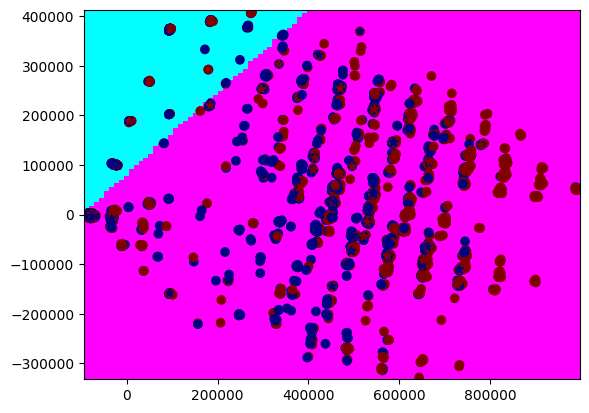

In [15]:
plot_decision_boundaries(model, Xnew_test, y_predict, y_test)

In [16]:
for k in [2, 5, 10, 20, 30]:
    pca = PCA(n_components=k, random_state=42)
    pca.fit(X_train)
    Xtr = pca.transform(X_train)
    Xte = pca.transform(X_test)

    model = Pipeline(steps=[
        ('normalizer', StandardScaler()),
        ('classifier', LogisticRegression())
    ])
    model.fit(Xtr, y_train)
    yhat = model.predict(Xte)
    errors = np.sum(yhat != y_test)
    acc = 1 - errors / len(y_test)
    print(f"n_components={k} -> errors: {errors}, accuracy: {acc:.4f}")


n_components=2 -> errors: 18876, accuracy: 0.5129
n_components=5 -> errors: 18185, accuracy: 0.5307
n_components=10 -> errors: 13731, accuracy: 0.6457
n_components=20 -> errors: 12295, accuracy: 0.6827
n_components=30 -> errors: 6578, accuracy: 0.8303


On voit bien que si on augmente le nombre de features on a une meilleure précision de l'algorithme

In [17]:
for k in [2, 5, 10, 20, 30]:
    pca = PCA(n_components=k, random_state=42)
    pca.fit(X_train)
    Xtr = pca.transform(X_train)
    Xte = pca.transform(X_test)

    model = Pipeline(steps=[
        ('normalizer', StandardScaler()),
        ('classifier', RandomForestClassifier())
    ])
    model.fit(Xtr, y_train)
    yhat = model.predict(Xte)
    errors = np.sum(yhat != y_test)
    acc = 1 - errors / len(y_test)
    print(f"n_components={k} -> errors: {errors}, accuracy: {acc:.4f}")


n_components=2 -> errors: 5494, accuracy: 0.8582
n_components=5 -> errors: 5119, accuracy: 0.8679
n_components=10 -> errors: 3481, accuracy: 0.9102
n_components=20 -> errors: 3673, accuracy: 0.9052
n_components=30 -> errors: 2434, accuracy: 0.9372


We have maximal precision when we have more than 2 features as expected, we verified this with 2 models namely: Logistic Regression and Random Forest.

### DISCUSSION

In this project, we applied several machine learning classification methods to predict the outcome of League of Legends matches based on in game statistics such as gold earned, damage dealt, and objectives taken. After preprocessing the data (handling missing values, encoding categorical variables etc.) we trained multiple classifiers including Logistic Regression, SVM, KNN, Decision Tree, and Random Forest. The Random Forest model achieved the best accuracy. 

PCA for dimensionality reduction reduced the number of features to two, which allowed the visualization of decision boundaries but also increasing prediction errors by about 2.8 times, as information was lost. 

Overall, the models predicted meaningful patterns from a huge number of matches played in a complex strategy game.